In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/gender_submission.csv
/kaggle/input/titanic/test.csv


In [2]:
train_df=pd.read_csv('/kaggle/input/titanic/train.csv')
test_df=pd.read_csv('/kaggle/input/titanic/test.csv')

In [3]:
train_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
final_df=pd.concat([train_df,test_df])

In [6]:
final_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [7]:
final_df.shape

(1309, 12)

In [8]:
final_df.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.038354,0.028814,-0.055224,0.008942,0.031428
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.038354,-0.338481,1.000000,-0.408106,0.060832,0.018322,-0.558629
Age,0.028814,-0.077221,-0.408106,1.000000,-0.243699,-0.150917,0.178740
SibSp,-0.055224,-0.035322,0.060832,-0.243699,1.000000,0.373587,0.160238
Parch,0.008942,0.081629,0.018322,-0.150917,0.373587,1.000000,0.221539
Fare,0.031428,0.257307,-0.558629,0.178740,0.160238,0.221539,1.000000


In [9]:
final_df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

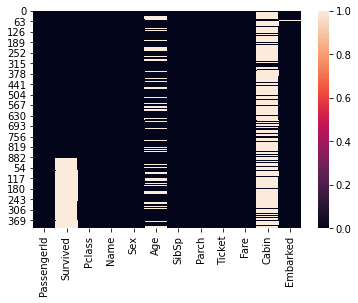

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(final_df.isnull())

In [11]:
def bar_charts(feature):
    survived=final_df[final_df['Survived']==1][feature].value_counts()
    dead=final_df[final_df['Survived']==0][feature].value_counts()
    new_df=pd.DataFrame([survived,dead])
    new_df.index=['Survived','Dead']
    new_df.plot(kind='bar',stacked=True,figsize=(10,5))

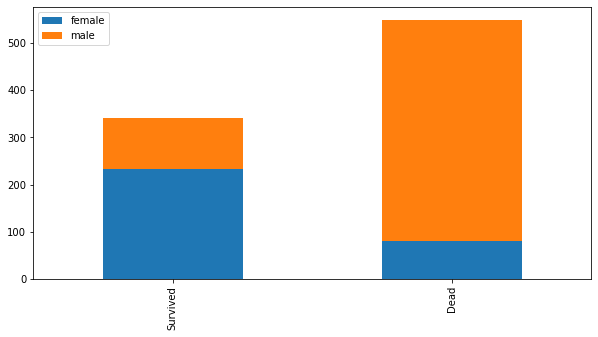

In [12]:
bar_charts('Sex')

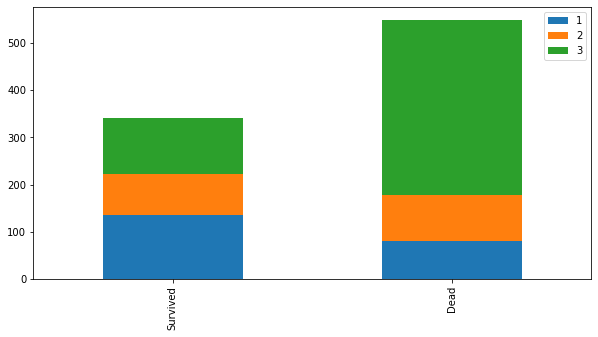

In [13]:
bar_charts('Pclass')

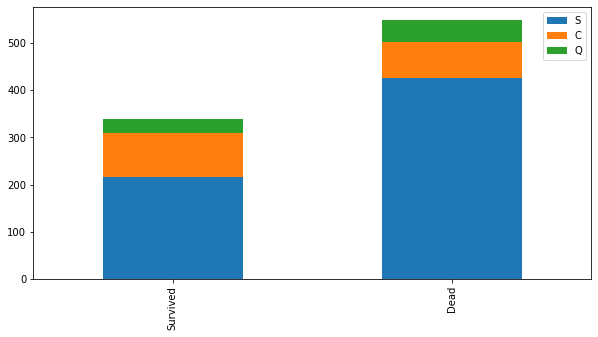

In [14]:
bar_charts('Embarked')

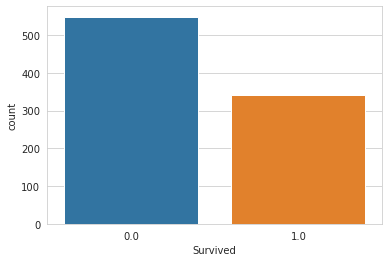

In [15]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',data=final_df)

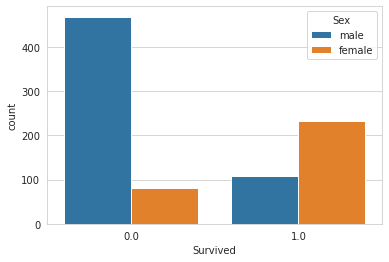

In [16]:
sns.countplot(x='Survived',hue='Sex',data=final_df)

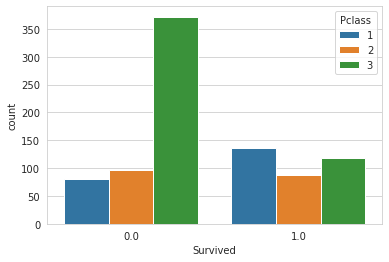

In [17]:
sns.countplot(x='Survived',hue='Pclass',data=final_df)

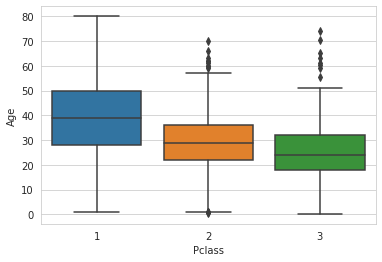

In [18]:
sns.boxplot(x='Pclass',y='Age',data=final_df)

In [19]:
final_df['Age']=np.where(final_df['Pclass']==1,40,27)
test_df['Age']=np.where(test_df['Pclass']==1,40,27)

In [20]:
final_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,27,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,40,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,27,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,40,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,27,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,27,0,0,A.5. 3236,8.0500,NaN,S
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,40,0,0,PC 17758,108.9000,C105,C
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,27,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,NaN,3,"Ware, Mr. Frederick",male,27,0,0,359309,8.0500,NaN,S


In [21]:
final_df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [22]:
final_df=final_df.drop(['Cabin'],axis=1)
test_df=test_df.drop(['Cabin'],axis=1)

In [23]:
final_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,27,1,0,A/5 21171,7.2500,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,40,1,0,PC 17599,71.2833,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,27,0,0,STON/O2. 3101282,7.9250,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,40,1,0,113803,53.1000,S
4,5,0.0,3,"Allen, Mr. William Henry",male,27,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,27,0,0,A.5. 3236,8.0500,S
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,40,0,0,PC 17758,108.9000,C
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,27,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,NaN,3,"Ware, Mr. Frederick",male,27,0,0,359309,8.0500,S


In [24]:
final_df=final_df.dropna()

In [25]:
final_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,27,1,0,A/5 21171,7.2500,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,40,1,0,PC 17599,71.2833,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,27,0,0,STON/O2. 3101282,7.9250,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,40,1,0,113803,53.1000,S
4,5,0.0,3,"Allen, Mr. William Henry",male,27,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0.0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13.0000,S
887,888,1.0,1,"Graham, Miss. Margaret Edith",female,40,0,0,112053,30.0000,S
888,889,0.0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,27,1,2,W./C. 6607,23.4500,S
889,890,1.0,1,"Behr, Mr. Karl Howell",male,40,0,0,111369,30.0000,C


In [26]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
final_df['Sex']=le.fit_transform(final_df['Sex'])
test_df['Sex']=le.fit_transform(test_df['Sex'])

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [27]:
final_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",1,27,1,0,A/5 21171,7.2500,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,40,1,0,PC 17599,71.2833,C
2,3,1.0,3,"Heikkinen, Miss. Laina",0,27,0,0,STON/O2. 3101282,7.9250,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,40,1,0,113803,53.1000,S
4,5,0.0,3,"Allen, Mr. William Henry",1,27,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0.0,2,"Montvila, Rev. Juozas",1,27,0,0,211536,13.0000,S
887,888,1.0,1,"Graham, Miss. Margaret Edith",0,40,0,0,112053,30.0000,S
888,889,0.0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,27,1,2,W./C. 6607,23.4500,S
889,890,1.0,1,"Behr, Mr. Karl Howell",1,40,0,0,111369,30.0000,C


In [28]:
final_df['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [29]:
embark=pd.get_dummies(final_df['Embarked'],drop_first=True)
embark_2=pd.get_dummies(test_df['Embarked'],drop_first=True)


In [30]:
final_df=final_df.drop(['Ticket','Name','Embarked'],axis=1)
test_df=test_df.drop(['Ticket','Name','Embarked'],axis=1)

In [31]:
test_df

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare
0,892,3,1,27,0,0,7.8292
1,893,3,0,27,1,0,7.0000
2,894,2,1,27,0,0,9.6875
3,895,3,1,27,0,0,8.6625
4,896,3,0,27,1,1,12.2875
...,...,...,...,...,...,...,...
413,1305,3,1,27,0,0,8.0500
414,1306,1,0,40,0,0,108.9000
415,1307,3,1,27,0,0,7.2500
416,1308,3,1,27,0,0,8.0500


In [32]:
test_df=pd.concat([test_df,embark_2],axis=1)


In [33]:
test_df

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Q,S
0,892,3,1,27,0,0,7.8292,1,0
1,893,3,0,27,1,0,7.0000,0,1
2,894,2,1,27,0,0,9.6875,1,0
3,895,3,1,27,0,0,8.6625,0,1
4,896,3,0,27,1,1,12.2875,0,1
...,...,...,...,...,...,...,...,...,...
413,1305,3,1,27,0,0,8.0500,0,1
414,1306,1,0,40,0,0,108.9000,0,0
415,1307,3,1,27,0,0,7.2500,0,1
416,1308,3,1,27,0,0,8.0500,0,1


In [34]:
test_df.isnull().sum()

PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           1
Q              0
S              0
dtype: int64

In [35]:
test_df=test_df.fillna(method='ffill')

In [36]:
test_df.isnull().sum()

PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Q              0
S              0
dtype: int64

In [37]:
final_df=pd.concat([final_df,embark],axis=1)

In [38]:
final_df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Q,S
0,1,0.0,3,1,27,1,0,7.2500,0,1
1,2,1.0,1,0,40,1,0,71.2833,0,0
2,3,1.0,3,0,27,0,0,7.9250,0,1
3,4,1.0,1,0,40,1,0,53.1000,0,1
4,5,0.0,3,1,27,0,0,8.0500,0,1
...,...,...,...,...,...,...,...,...,...,...
886,887,0.0,2,1,27,0,0,13.0000,0,1
887,888,1.0,1,0,40,0,0,30.0000,0,1
888,889,0.0,3,0,27,1,2,23.4500,0,1
889,890,1.0,1,1,40,0,0,30.0000,0,0


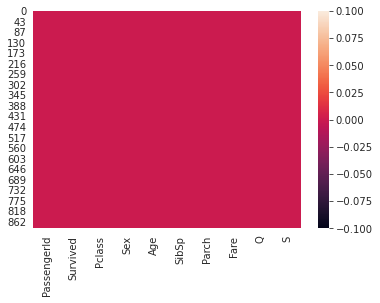

In [39]:
sns.heatmap(final_df.isnull())

In [40]:
x=final_df.drop(['Survived'],axis=1)
y=final_df['Survived']

In [41]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=0,test_size=0.2)

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
lr=LogisticRegression(C=3,max_iter=2000)
lr.fit(x_train,y_train)
pred_y=lr.predict(test_df)



In [43]:
submission=pd.DataFrame({'PassengerId':test_df['PassengerId'],
                        'Survived':pred_y})

In [44]:
submission.to_csv('submission.csv',index=False)



In [45]:
submission

,PassengerId,Survived
0,892,0.0
1,893,1.0
2,894,0.0
3,895,0.0
4,896,1.0
...,...,...
413,1305,0.0
414,1306,1.0
415,1307,0.0
416,1308,0.0
